# Notebook: Clasificación HAM10000 con CoAtNet-0

## 1: Instalación de dependencias

In [1]:
# Parámetros de configuración

import os

# 1. Forzamos modo Legacy para CoAtNet
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# 2. Quitamos el aviso de oneDNN (para que el log sea más limpio)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 124
DATA_PATH = "datasets/ham10000/organized_ham10000"
META_PATH = "datasets/ham10000/HAM10000_metadata.csv"
AUTOTUNE = tf.data.AUTOTUNE

# tf.keras.mixed_precision.set_global_policy('mixed_float16')

2026-05-23 16:18:05.158609: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-23 16:18:05.869255: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Instalación definitiva y limpieza de conflictos
%pip install -q \
    "tensorflow[and-cuda]==2.16.1" \
    tf-keras==2.16.0 \
    keras-cv==0.9.0 \
    keras-cv-attention-models \
    pandas matplotlib scikit-learn ipywidgets seaborn \
    lime shap opencv-python \
    python-dotenv kaggle \
    optuna optuna-dashboard optuna-integration \
    pydot


# Borramos Keras 3 justo después por si TensorFlow lo ha vuelto a instalar
# %pip uninstall -y keras keras-core

# Hay que instalar manualmente graphviz
# sudo apt install graphviz

# Después tendrás que reiniciar el kernel

# Cargamos las variables de entorno del archivo .env
import os
from dotenv import load_dotenv

# Carga las variables del archivo .env al entorno del sistema
load_dotenv()


# 3. LE INDICAMOS A TENSORFLOW DÓNDE ESTÁN TUS LIBRERÍAS DE NVIDIA
# Buscamos las que instaló el comando [and-cuda] arriba
import site
for path in site.getsitepackages():
    nvidia_path = os.path.join(path, "nvidia/cudnn/lib")
    if os.path.exists(nvidia_path):
        os.environ["LD_LIBRARY_PATH"] = nvidia_path + ":" + os.environ.get("LD_LIBRARY_PATH", "")

# Añadimos la ruta del driver de Windows en WSL2
os.environ["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + os.environ.get("LD_LIBRARY_PATH", "")


# Comprobación de la 3080 Ti
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"🔥 ¡CONSEGUIDO! GPU lista: {gpus[0]}")
else:
    print("❌ Seguimos sin ver la GPU. Mira el error de arriba.")


import subprocess

# Guardamos todo el script bash en un string triple
bash_script = """
# 1. Definir rutas relativas al proyecto
PROJECT_ROOT=$(pwd)
DATA_DIR="$PROJECT_ROOT/datasets/ham10000"
ZIP_FILE="$DATA_DIR/ham10000-preprocessed.zip"
WITNESS_DIR="$DATA_DIR/organized_ham10000"
META_FILE="$DATA_DIR/HAM10000_metadata.csv"

# 2. Crear la carpeta base si no existe
mkdir -p "$DATA_DIR"

# 3. Lógica para las IMÁGENES
if [ -d "$WITNESS_DIR" ]; then
    echo "✅ Escenario A: Las carpetas de imágenes ya existen en $WITNESS_DIR. Saltando descarga."
elif [ -f "$ZIP_FILE" ]; then
    echo "📦 Escenario B: ZIP de imágenes encontrado pero no descomprimido. Extrayendo ahora..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
    echo "✅ Descompresión terminada y ZIP eliminado."
else
    echo "🌐 Escenario C: No hay imágenes. Iniciando descarga desde Kaggle..."
    curl -L -o "$ZIP_FILE" https://www.kaggle.com/api/v1/datasets/download/rayeedaabir/ham10000-preprocessed
    echo "🚚 Descarga de imágenes finalizada. Descomprimiendo..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
fi

# 4. Lógica para los METADATOS
if [ -f "$META_FILE" ]; then
    echo "✅ Metadatos encontrados en $META_FILE."
else
    echo "📊 Los metadatos no existen. Descargando HAM10000_metadata.csv..."
    kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -f HAM10000_metadata.csv -p "$DATA_DIR"
    
    if [ -f "$DATA_DIR/HAM10000_metadata.csv.zip" ]; then
        unzip -o "$DATA_DIR/HAM10000_metadata.csv.zip" -d "$DATA_DIR"
        rm "$DATA_DIR/HAM10000_metadata.csv.zip"
    fi
    
    echo "✅ Metadatos listos."
fi

echo "🚀 Proceso completo. Imágenes y metadatos preparados en $DATA_DIR"
"""

# Ejecutamos el string como un script de bash directamente desde Python
subprocess.run(bash_script, shell=True, executable='/bin/bash')

import tensorflow as tf


def get_class_name_es(input_data):
    """
    Traduce las categorías de HAM10000 al español.
    Soporta códigos cortos ('mel') y nombres largos ('Melanoma').
    """
    translations = {
        # Mapeo para nombres largos (los que tienes ahora)
        'actinic keratoses': 'Queratosis actínica',
        'basal cell carcinoma': 'Carcinoma basocelular',
        'benign keratosis': 'Queratosis benigna',
        'dermatofibroma': 'Dermatofibroma',
        'melanocytic nevi': 'Nevus melanocítico',
        'melanoma': 'Melanoma',
        'vascular lesions': 'Lesión vascular',
        
        # Mapeo para códigos cortos (por si acaso)
        'akiec': 'Queratosis actínica',
        'bcc': 'Carcinoma basocelular',
        'bkl': 'Queratosis benigna',
        'df': 'Dermatofibroma',
        'nv': 'Nevus melanocítico',
        'mel': 'Melanoma',
        'vasc': 'Lesión vascular'
    }
    
    def translate(name):
        # Limpiamos el texto: minúsculas y quitar espacios en los extremos
        clean_name = str(name).lower().strip()
        return translations.get(clean_name, name)

    # Si recibimos una lista
    if isinstance(input_data, list):
        return [translate(name) for name in input_data]
    
    # Si recibimos un solo nombre
    return translate(input_data)


import pandas as pd
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit

# 1. Cargar metadatos
df = pd.read_csv(META_PATH)
df.set_index('image_id', inplace=True) # Facilita la búsqueda por ID

# 2. Mapeo de rutas de archivos (SIN PROCESAR METADATOS AÚN)
all_image_paths = []
all_labels = []
all_img_ids = []

class_names = sorted(os.listdir(DATA_PATH))  
folder_to_id = {name: i for i, name in enumerate(class_names)}

for folder in class_names:
    folder_path = os.path.join(DATA_PATH, folder)
    if not os.path.isdir(folder_path): continue
    for img_name in os.listdir(folder_path):
        if img_name.endswith('.jpg'):
            img_id = img_name.replace('.jpg', '')
            if img_id in df.index:
                all_image_paths.append(os.path.join(folder_path, img_name))
                all_labels.append(folder_to_id[folder])
                all_img_ids.append(img_id)

# Creamos el dataframe base combinando rutas con la edad y categorías CRUDA
data_df = pd.DataFrame({
    'path': all_image_paths,
    'label': all_labels,
    'image_id': all_img_ids
})
# Hacemos merge de los metadatos crudos
data_df = data_df.merge(df[['lesion_id', 'age', 'sex', 'localization']], left_on='image_id', right_index=True)

# ==========================================
# 3. DIVISIÓN DEL DATAFRAME (ANTES DEL SCALER)
# ==========================================

# 1. Separar Test (15%) asegurando que las fotos de la misma lesión no se separen
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(data_df, data_df['label'], groups=data_df['lesion_id']))

train_val_df = data_df.iloc[train_val_idx].copy()
test_df = data_df.iloc[test_idx].copy()

# 2. Separar Val (15% del total -> ~17.6% del remanente) agrupando de nuevo
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx, val_idx = next(gss_val.split(train_val_df, train_val_df['label'], groups=train_val_df['lesion_id']))

train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

print(f"✅ Split Seguro. Pacientes únicos (lesiones) en Train: {train_df['lesion_id'].nunique()}")
print(f"✅ Pacientes únicos (lesiones) en Test: {test_df['lesion_id'].nunique()}")

# Comprobación de seguridad matemática (Si esto da más de 0, algo ha fallado)
fugas = set(train_df['lesion_id']).intersection(set(test_df['lesion_id']))
assert len(fugas) == 0, f"¡ERROR DE DATA LEAKAGE! Hay {len(fugas)} pacientes en Train y Test a la vez."

# ==========================================
# 4. PREPROCESAMIENTO
# ==========================================

# A. Rellenar nulos (Solo usando la media de Train)
mean_age = train_df['age'].mean()
train_df['age'] = train_df['age'].fillna(mean_age)
val_df['age'] = val_df['age'].fillna(mean_age)
test_df['age'] = test_df['age'].fillna(mean_age)

# B. Escalado de la edad (fit solo en Train)
scaler = StandardScaler()
train_age_scaled = scaler.fit_transform(train_df[['age']])
val_age_scaled = scaler.transform(val_df[['age']])
test_age_scaled = scaler.transform(test_df[['age']])

# C. Encoding (fit solo en Train, handle_unknown ignora categorías nuevas en Test)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_cat = encoder.fit_transform(train_df[['sex', 'localization']])
val_cat = encoder.transform(val_df[['sex', 'localization']])
test_cat = encoder.transform(test_df[['sex', 'localization']])



# D. Agrupar los features escalados en una lista por fila para facilitar la extracción
train_df['meta'] = list(np.hstack([train_age_scaled, train_cat]).astype(np.float32))
val_df['meta'] = list(np.hstack([val_age_scaled, val_cat]).astype(np.float32))
test_df['meta'] = list(np.hstack([test_age_scaled, test_cat]).astype(np.float32))

# ==========================================
# 5. EXTRACCIÓN DE VARIABLES FINALES (¡SIN BALANCEAR!)
# ==========================================

# --- Extraer variables usando directamente el set original desbalanceado ---
train_paths = train_df['path'].values
train_meta = np.stack(train_df['meta'].values)
train_labels = train_df['label'].values 

val_paths = val_df['path'].values
val_meta = np.stack(val_df['meta'].values)
val_labels = val_df['label'].values

test_paths = test_df['path'].values
test_meta = np.stack(test_df['meta'].values)
test_labels = test_df['label'].values

print(f"📊 Reparto final: Train ({len(train_paths)}), Val ({len(val_paths)}), Test ({len(test_paths)})")

# ==========================================
# 6. FUNCIÓN DE PROCESAMIENTO Y TF.DATA
# ==========================================

def process_data(image_path, metadata, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    
    # 1. Pasamos a float32 y escalamos a [0, 1]
    img = tf.cast(img, tf.float32) / 255.0
    
    # 2. NORMALIZACIÓN RESTAURADA (Para el Estudio 2)
    mean = tf.constant([0.485, 0.456, 0.406], shape=[1, 1, 3], dtype=tf.float32)
    std = tf.constant([0.229, 0.224, 0.225], shape=[1, 1, 3], dtype=tf.float32)
    img = (img - mean) / std
    
    return (img, metadata), tf.one_hot(label, depth=7)

# --- Dataset de Entrenamiento ---
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.cache() # Cachear antes en memoria RAM
train_ds = train_ds.shuffle(len(train_paths)) # Shuffle de imágenes individuales ANTES del map/batch
train_ds = train_ds.map(process_data, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Dataset de Validación ---
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.cache()
val_ds = val_ds.map(process_data, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# --- Dataset de Test ---
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_meta, test_labels))
test_ds = test_ds.cache()
test_ds = test_ds.map(process_data, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("✅ Datasets creados con éxito, variables sincronizadas, TODOS los datos incluidos y SIN data leakage.")

class_names_es = get_class_name_es(class_names)
print(f"✅ Clases detectadas (IDs): {class_names}")
print(f"🇪🇸 Traducción: {class_names_es}")


Note: you may need to restart the kernel to use updated packages.
🔥 ¡CONSEGUIDO! GPU lista: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✅ Escenario A: Las carpetas de imágenes ya existen en /home/herraiz/proyectos/TFM/datasets/ham10000/organized_ham10000. Saltando descarga.
✅ Metadatos encontrados en /home/herraiz/proyectos/TFM/datasets/ham10000/HAM10000_metadata.csv.
🚀 Proceso completo. Imágenes y metadatos preparados en /home/herraiz/proyectos/TFM/datasets/ham10000


2026-05-23 16:18:07.928364: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-23 16:18:08.044737: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-23 16:18:08.044792: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


✅ Split Seguro. Pacientes únicos (lesiones) en Train: 5231
✅ Pacientes únicos (lesiones) en Test: 1121
📊 Reparto final: Train (6963), Val (1525), Test (1527)
✅ Datasets creados con éxito, variables sincronizadas, TODOS los datos incluidos y SIN data leakage.
✅ Clases detectadas (IDs): ['Actinic Keratoses', 'Basal Cell Carcinoma', 'Benign Keratosis', 'Dermatofibroma', 'Melanocytic Nevi', 'Melanoma', 'Vascular Lesions']
🇪🇸 Traducción: ['Queratosis actínica', 'Carcinoma basocelular', 'Queratosis benigna', 'Dermatofibroma', 'Nevus melanocítico', 'Melanoma', 'Lesión vascular']


2026-05-23 16:18:08.510388: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-23 16:18:08.510470: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-23 16:18:08.510489: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-23 16:18:08.862837: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-23 16:18:08.862928: I external/local_xla/xla/stream_executor

## 6: Búsqueda de hiperparámetros

Primero configuramos Optuna como optimizador:

In [3]:
import optuna
storage_name = "sqlite:///optuna_tfm.db"
print(f"✅ Optuna DB lista en {storage_name}")


# --- CONFIGURACIÓN DE FLUJO ---
SKIP_TRAINING = False     # True: Carga el modelo | False: Entrena
RUN_OPTIMIZATION = True   # True: Busca mejores parámetros | False: Usa los mejores ya encontrados o defaults
TRAIN_FINAL_MODEL = True  # True: Entrena el modelo final con los mejores parámetros | False: Solo carga
TRIALS = 15      


MODEL_NAME = "CoAtNet0"
STUDY_NAME = "C0_with_standardization_mean_float32_zoom_fix"

✅ Optuna DB lista en sqlite:///optuna_tfm.db


In [4]:
from keras_cv_attention_models import coatnet
from optuna_integration import TFKerasPruningCallback
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
import keras_cv_attention_models
import gc
import datetime
import optuna
import tensorflow as tf
import traceback
import numpy as np

print(f"Lanzando estudio de Optuna: {STUDY_NAME}")

FINAL_ZOOM_FACTOR = 0.10
FINAL_ROTATION_PROB = 0.5

zoom_layer = tf.keras.layers.RandomZoom(
    height_factor=(-FINAL_ZOOM_FACTOR, 0.0), 
    width_factor=(-FINAL_ZOOM_FACTOR, 0.0),
    name="zoom_pipeline"
)

def augment_stateless(image):
    # 1. Rotación aleatoria existente
    if tf.random.uniform([]) < FINAL_ROTATION_PROB:
        image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, tf.int32))
    
    # 2. Aplicar el zoom en el pipeline de CPU (forzando training=True)
    image = zoom_layer(image, training=True)
    return image

# El pipeline de datos se mantiene igual, pero ahora ejecutará ambas transformaciones en paralelo mediante CPU
train_ds_aug = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds_aug = train_ds_aug.shuffle(2000).map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_aug = train_ds_aug.map(
    lambda inputs, label: ((augment_stateless(inputs[0]), inputs[1]), label),
    num_parallel_calls=tf.data.AUTOTUNE
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


pesos_balanceados = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(train_labels),    
    y=train_labels
)

alpha_weights = list(pesos_balanceados.astype(np.float32))

alpha_weights[0] *= 1.2 
alpha_weights[1] *= 1.4 
alpha_weights[5] *= 1.5 
alpha_weights[3] *= 0.5  


print("Pesos calculados para cada clase (Alpha):")
for i, peso in enumerate(alpha_weights):
    print(f"Clase {i}: {peso:.4f}")


class TimestampCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"\nInicio Época {epoch + 1}: {hora_actual}")

    def on_epoch_end(self, epoch, logs=None):
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"Fin Época {epoch + 1}: {hora_actual}")

def objective(trial):
    try:
        tf.keras.backend.clear_session()
        gc.collect()

        lr = trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True)
        dropout = trial.suggest_float("dropout", 0.2, 0.5)
        meta_units = trial.suggest_int("meta_units", 16, 32)
        meta_layers = trial.suggest_int("meta_layers", 1, 3)
        
        input_img = layers.Input(shape=(224, 224, 3), name="image_input")
        
        base_model = keras_cv_attention_models.coatnet.CoAtNet0(
            input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet"
        )
        base_model.trainable = False # No entrenamos en la búsqueda de hiperparámetros para ahorrar tiempo/memoria
        
        img_features = layers.GlobalAveragePooling2D()(base_model(input_img))

        input_meta = layers.Input(shape=(19,), name="meta_input")
        x_meta = input_meta
        for i in range(meta_layers):
            x_meta = layers.Dense(meta_units, activation="relu")(x_meta)
            x_meta = layers.BatchNormalization()(x_meta)

        combined = layers.Concatenate()([img_features, x_meta])
        x = layers.Dense(256, activation="relu")(combined)
        x = layers.Dropout(dropout)(x)
        # output = layers.Dense(7, activation="softmax")(x)
        output = layers.Dense(7, activation="softmax", dtype="float32", name="predictions")(x)

        model = models.Model(inputs=[input_img, input_meta], outputs=output)
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=alpha_weights, gamma=2.0),
            metrics=[
                'accuracy',
                tf.keras.metrics.Recall(class_id=4, name='recall_melanoma'),     
                tf.keras.metrics.Recall(class_id=1, name='recall_bcc'),          
                tf.keras.metrics.Recall(class_id=0, name='recall_actinica')      
            ],
            jit_compile=False # Evitamos que se use XLA para que no haya problemas con Optuna y la GPU en WSL2
        )

        lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=0
        )
        
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8, restore_best_weights=True, verbose=0
        )
        
        timestamp_cb = TimestampCallback()

        history = model.fit(
            train_ds_aug,
            validation_data=val_ds, 
            epochs=50, 
            callbacks=[
                lr_scheduler,
                early_stop, 
                timestamp_cb,
                TFKerasPruningCallback(trial, "val_loss") 
            ],
            verbose=0
        )

        return min(history.history["val_loss"])

    except optuna.exceptions.TrialPruned as e:
        raise e

    except Exception as e:
            print(f"\nEl Trial {trial.number} ha crasheado:")
            print(traceback.format_exc()) 
            raise e
    
    finally:
        for var in ['model', 'base_model']:
            if var in locals():
                del locals()[var]
                
        tf.keras.backend.clear_session()
        gc.collect()

study = optuna.create_study(
    direction="minimize", 
    storage=storage_name, 
    study_name=STUDY_NAME, 
    load_if_exists=True
)

Lanzando estudio de Optuna: C0_with_standardization_mean_float32_zoom_fix
Pesos calculados para cada clase (Alpha):
Clase 0: 5.3768
Clase 1: 3.9903
Clase 2: 1.2918
Clase 3: 5.4061
Clase 4: 0.2132
Clase 5: 1.9352
Clase 6: 10.5821


[I 2026-05-23 16:18:12,279] A new study created in RDB with name: C0_with_standardization_mean_float32_zoom_fix


Ahora empezamos los trials del entrenamiento. Con el parámetro skip_training a "True" podemos saltarlo y usar el mejor modelo ya entrenado.

In [5]:
optuna.logging.set_verbosity(optuna.logging.DEBUG)                                                                                               
 
 # 1. EJECUCIÓN DE OPTUNA
if not SKIP_TRAINING and RUN_OPTIMIZATION:
    print(f"🔥 Lanzando optimización con Optuna (n_trials={TRIALS})...")
    study.optimize(objective, n_trials=TRIALS)
    print("✅ Optimización completada.")
    
    # Vaciamos la memoria del último modelo de Optuna para dejar sitio al Modelo Final
    tf.keras.backend.clear_session()
    gc.collect()

# 2. SELECCIÓN DE PARÁMETROS
# Filtramos para ver si hay algún trial que haya terminado con éxito
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

if len(completed_trials) > 0:
    best_params = study.best_params
    print(f"📈 Usando mejores parámetros encontrados por Optuna:")
    for key, value in best_params.items():
        print(f"   - {key}: {value}")
else:
    best_params = {
        'learning_rate': 1e-4, 
        'dropout': 0.3, 
        'meta_units': 32,       
        'meta_layers': 2,       
        'zoom_factor': 0.1,     
        'rotation_prob': 0.5    
    }
    print(f"⚠️ No hay historial de éxito en la DB. Usando parámetros por defecto: {best_params}")

🔥 Lanzando optimización con Optuna (n_trials=15)...
>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5

Inicio Época 1: 16:18:14


2026-05-23 16:18:34.695492: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1779549517.490525  631487 service.cc:145] XLA service 0x726f7b950ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779549517.490750  631487 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti, Compute Capability 8.6
2026-05-23 16:18:37.497153: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779549517.641050  631487 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Fin Época 1: 16:19:00

Inicio Época 2: 16:19:00
Fin Época 2: 16:19:19

Inicio Época 3: 16:19:19
Fin Época 3: 16:19:39

Inicio Época 4: 16:19:39
Fin Época 4: 16:20:00

Inicio Época 5: 16:20:00
Fin Época 5: 16:20:21

Inicio Época 6: 16:20:21
Fin Época 6: 16:20:41

Inicio Época 7: 16:20:41
Fin Época 7: 16:21:01

Inicio Época 8: 16:21:01
Fin Época 8: 16:21:21

Inicio Época 9: 16:21:21
Fin Época 9: 16:21:40

Inicio Época 10: 16:21:40
Fin Época 10: 16:21:59

Inicio Época 11: 16:21:59
Fin Época 11: 16:22:19

Inicio Época 12: 16:22:19
Fin Época 12: 16:22:38

Inicio Época 13: 16:22:38
Fin Época 13: 16:22:57

Inicio Época 14: 16:22:57
Fin Época 14: 16:23:17

Inicio Época 15: 16:23:17
Fin Época 15: 16:23:36

Inicio Época 16: 16:23:36
Fin Época 16: 16:23:55

Inicio Época 17: 16:23:55
Fin Época 17: 16:24:14

Inicio Época 18: 16:24:14
Fin Época 18: 16:24:34

Inicio Época 19: 16:24:34
Fin Época 19: 16:24:53

Inicio Época 20: 16:24:54
Fin Época 20: 16:25:14

Inicio Época 21: 16:25:14
Fin Época 21: 16:

[I 2026-05-23 16:26:53,648] Trial 0 finished with value: 0.7874525189399719 and parameters: {'learning_rate': 0.0004960987121680983, 'dropout': 0.28316732770717756, 'meta_units': 19, 'meta_layers': 2}. Best is trial 0 with value: 0.7874525189399719.


>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5

Inicio Época 1: 16:26:55
Fin Época 1: 16:27:27

Inicio Época 2: 16:27:27
Fin Época 2: 16:27:46

Inicio Época 3: 16:27:46
Fin Época 3: 16:28:06

Inicio Época 4: 16:28:06
Fin Época 4: 16:28:25

Inicio Época 5: 16:28:25
Fin Época 5: 16:28:45

Inicio Época 6: 16:28:45
Fin Época 6: 16:29:05

Inicio Época 7: 16:29:05
Fin Época 7: 16:29:26

Inicio Época 8: 16:29:26
Fin Época 8: 16:29:45

Inicio Época 9: 16:29:45
Fin Época 9: 16:30:05

Inicio Época 10: 16:30:05
Fin Época 10: 16:30:24

Inicio Época 11: 16:30:24
Fin Época 11: 16:30:44

Inicio Época 12: 16:30:44
Fin Época 12: 16:31:03

Inicio Época 13: 16:31:03
Fin Época 13: 16:31:22

Inicio Época 14: 16:31:22
Fin Época 14: 16:31:41

Inicio Época 15: 16:31:41
Fin Época 15: 16:32:01

Inicio Época 16: 16:32:01
Fin Época 16: 16:32:21

Inicio Época 17: 16:32:21
Fin Época 17: 16:32:40

Inicio Época 18: 16:32:40
Fin Época 18: 16:33:00

Inicio Época 19: 16:33:00
Fin Época 1

...

>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5

Inicio Época 1: 17:29:02
Fin Época 1: 17:29:36


[I 2026-05-23 17:29:36,691] Trial 13 pruned. Trial was pruned at epoch 0.


>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5

Inicio Época 1: 17:29:39
Fin Época 1: 17:30:12


[I 2026-05-23 17:30:13,194] Trial 14 pruned. Trial was pruned at epoch 0.


✅ Optimización completada.
📈 Usando mejores parámetros encontrados por Optuna:
   - learning_rate: 0.0004960987121680983
   - dropout: 0.28316732770717756
   - meta_units: 19
   - meta_layers: 2


## 7. Entrenamiento del modelo final

In [6]:
MODEL_PATH = f'models/{STUDY_NAME}.keras' # Ojo: he quitado la barra inicial (/) para que no intente guardar en la raíz del disco duro

if TRAIN_FINAL_MODEL:
    # 1. Recuperar los mejores parámetros (Solo los que Optuna optimizó)
    if 'best_params' not in locals():
        best_params = {
            'learning_rate': 1e-4, 'dropout': 0.3, 'meta_units': 32, 'meta_layers': 2
        }
    print(f"🏆 Mejores parámetros a usar: {best_params}")

    # ==========================================
    # APLICAR EL DATA AUGMENTATION FIJO (HARDCODED)
    # ==========================================
    FINAL_ZOOM_FACTOR = 0.10
    FINAL_ROTATION_PROB = 0.5
    
    # Capa anti-OOM de Keras
    zoom_layer = tf.keras.layers.RandomZoom(
        height_factor=(-FINAL_ZOOM_FACTOR, 0.0), 
        width_factor=(-FINAL_ZOOM_FACTOR, 0.0),
    )

    def final_augment_fn(image):
        if tf.random.uniform([]) < FINAL_ROTATION_PROB:
            image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, tf.int32))
            
        if FINAL_ZOOM_FACTOR > 0:
            image = tf.expand_dims(image, 0) # Añadir fake batch
            image = zoom_layer(image)
            image = tf.squeeze(image, 0)     # Quitar fake batch
            
        return image

    print("🔄 Generando Dataset Final con Data Augmentation...")
    train_ds_final = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
    train_ds_final = train_ds_final.shuffle(len(train_paths)).map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds_final = train_ds_final.map(
        lambda inputs, label: ((final_augment_fn(inputs[0]), inputs[1]), label),
        num_parallel_calls=tf.data.AUTOTUNE
    ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # ==========================================
    # 2. Reconstruir la arquitectura ganadora
    # ==========================================
    input_img = layers.Input(shape=(224, 224, 3), name="image_input")
    base_model = keras_cv_attention_models.coatnet.CoAtNet0(
        input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet"
    )
    base_model.trainable = False
    img_output = base_model(input_img)
    img_features = layers.GlobalAveragePooling2D()(img_output)

    input_meta = layers.Input(shape=(19,), name="meta_input")
    x_meta = input_meta
    for _ in range(best_params['meta_layers']):
        x_meta = layers.Dense(best_params['meta_units'], activation="relu")(x_meta)
        x_meta = layers.BatchNormalization()(x_meta)

    combined = layers.Concatenate()([img_features, x_meta])
    x = layers.Dense(256, activation="relu")(combined)
    x = layers.Dropout(best_params['dropout'])(x)
    # output = layers.Dense(7, activation="softmax")(x)
    output = layers.Dense(7, activation="softmax", dtype="float32", name="predictions")(x)

    final_model = models.Model(inputs=[input_img, input_meta], outputs=output)

    # ==========================================
    # 3. Compilar (ENFOQUE MÉDICO)
    # ==========================================
    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=alpha_weights,
         gamma=2.0),
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(class_id=4, name='recall_melanoma'),
            tf.keras.metrics.Recall(class_id=1, name='recall_bcc'),
            tf.keras.metrics.Recall(class_id=0, name='recall_actinica')
        ],
        jit_compile=False # Añadido por seguridad anti-OOM en el entrenamiento final
    )

    final_model.summary()

    tf.keras.utils.plot_model(final_model, show_shapes=True, dpi=60, show_layer_names=True, rankdir='TB', to_file='modelo_hibrido.png')

    # ==========================================
    # 4. Callbacks y Entrenamiento
    # ==========================================
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', 
            patience=10, 
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=MODEL_PATH,
            monitor='val_loss',     # Cambiamos esto: monitorizamos la pérdida focal
            save_best_only=True,
            mode='min',             # Queremos que la pérdida sea la MÍNIMA
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6, verbose=1
        )
    ]

    print("🚀 Entrenando el modelo definitivo...")
    final_model.fit(
        train_ds_final,
        validation_data=val_ds,
        epochs=60, 
        callbacks=callbacks
    )
    
    final_model.save("models/modelo_tfm_balanceado_backup.keras")


            
    tf.keras.backend.clear_session()
    gc.collect()

else:
    if os.path.exists(MODEL_PATH):
        print(f"📦 Cargando modelo final desde {MODEL_PATH}...")
        final_model = tf.keras.models.load_model(
            MODEL_PATH, 
            custom_objects={"CategoricalFocalCrossentropy": tf.keras.losses.CategoricalFocalCrossentropy}
        )
    else:
        print(f"❌ ERROR: TRAIN_FINAL_MODEL es False pero no encuentro {MODEL_PATH}")

🏆 Mejores parámetros a usar: {'learning_rate': 0.0004960987121680983, 'dropout': 0.28316732770717756, 'meta_units': 19, 'meta_layers': 2}
🔄 Generando Dataset Final con Data Augmentation...
>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 meta_input (InputLayer)     [(None, 19)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 19)                   380       ['meta_input[0][0]']          
                                                                                                  
 image_input (InputLayer)    [(None, 224, 224, 3)]        0         []                            
                       

## 8: Predicciones
En esta celda extraemos las etiquetas reales y generamos las predicciones del modelo sobre el set de validación.

In [7]:
def get_predictions(dataset, name=""):
    print(f"🔮 Generando predicciones sobre el set de {name}...")
    y_true = []
    y_pred = []
    
    # Iteramos sobre el dataset para obtener imágenes, metadatos y etiquetas reales
    for (images, meta), labels in dataset:
        # Predicción del modelo híbrido
        preds = final_model.predict((images, meta), verbose=0)
        
        # Guardamos la realidad (argmax de one-hot) y la predicción
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
        
    return np.array(y_true), np.array(y_pred)

# Definimos el nombre del archivo donde vivirán las variables
ARCHIVO_PREDICCIONES = "predicciones_modelo_hibrido.npz"

if TRAIN_FINAL_MODEL:
    # 1. Generamos las de ENTRENAMIENTO
    y_true_train, y_pred_train = get_predictions(train_ds, name="ENTRENAMIENTO")

    # 2. Generamos las de VALIDACIÓN
    y_true_val, y_pred_val = get_predictions(val_ds, name="VALIDACIÓN")

    # 3. Generamos las de TEST
    y_true_test, y_pred_test = get_predictions(test_ds, name="TEST")
    
    # --- GUARDAMOS LAS VARIABLES EN DISCO ---
    np.savez(ARCHIVO_PREDICCIONES, 
             y_true_train=y_true_train, y_pred_train=y_pred_train,
             y_true_val=y_true_val, y_pred_val=y_pred_val,
             y_true_test=y_true_test, y_pred_test=y_pred_test)
    
    print(f"✅ Predicciones guardadas correctamente en '{ARCHIVO_PREDICCIONES}'")
    print(f"📊 Análisis completado. Entrenamiento: {len(y_true_train)} imágenes | Validación: {len(y_true_val)} imágenes | Test: {len(y_true_test)} imágenes.")

else:
    # --- CARGAMOS LAS VARIABLES DESDE EL DISCO ---
    if os.path.exists(ARCHIVO_PREDICCIONES):
        print(f"📦 Cargando predicciones previas desde '{ARCHIVO_PREDICCIONES}'...")
        datos = np.load(ARCHIVO_PREDICCIONES)
        
        # Extraemos las variables para que estén disponibles en el entorno
        y_true_train = datos['y_true_train']
        y_pred_train = datos['y_pred_train']
        y_true_val   = datos['y_true_val']
        y_pred_val   = datos['y_pred_val']
        y_true_test  = datos['y_true_test']
        y_pred_test  = datos['y_pred_test']
        
        print(f"✅ Predicciones cargadas en memoria con éxito.")
        print(f"📊 Datos listos. Entrenamiento: {len(y_true_train)} imágenes | Validación: {len(y_true_val)} imágenes | Test: {len(y_true_test)} imágenes.")
        
    else:
        print(f"⚠️ No se encontró el archivo '{ARCHIVO_PREDICCIONES}'. Generándolas sobre la marcha...")
        # Generación de emergencia si falta el archivo
        y_true_train, y_pred_train = get_predictions(train_ds, name="ENTRENAMIENTO")
        y_true_val, y_pred_val     = get_predictions(val_ds, name="VALIDACIÓN")
        y_true_test, y_pred_test   = get_predictions(test_ds, name="TEST")

🔮 Generando predicciones sobre el set de ENTRENAMIENTO...


2026-05-23 17:36:40.293368: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🔮 Generando predicciones sobre el set de VALIDACIÓN...


2026-05-23 17:36:44.865320: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🔮 Generando predicciones sobre el set de TEST...
✅ Predicciones guardadas correctamente en 'predicciones_modelo_hibrido.npz'
📊 Análisis completado. Entrenamiento: 6963 imágenes | Validación: 1525 imágenes | Test: 1527 imágenes.


2026-05-23 17:36:49.547877: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 9: Métricas Globales y por Clase

Aquí verás el rendimiento del entrenamiento (si lo hubo) y el reporte detallado (Precisión, Recall, F1-Score) por cada tipo de lesión.

In [8]:
from sklearn.metrics import classification_report, accuracy_score

acc_train = accuracy_score(y_true_train, y_pred_train)
acc_val = accuracy_score(y_true_val, y_pred_val)
acc_test = accuracy_score(y_true_test, y_pred_test)

reporte_md = f"""

# Modelo {MODEL_NAME} - Estudio: {STUDY_NAME}

============================================================
RENDIMIENTO GLOBAL
   - Accuracy Entrenamiento: {acc_train:.4f}
   - Accuracy Validación:    {acc_val:.4f}
   - Accuracy Test:          {acc_test:.4f}
============================================================

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
{classification_report(y_true_test, y_pred_test, target_names=class_names_es)}

## 📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
{classification_report(y_true_val, y_pred_val, target_names=class_names_es)}

## 📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):
{classification_report(y_true_train, y_pred_train, target_names=class_names_es)}
"""

print(reporte_md)

os.makedirs('results', exist_ok=True)
ruta_archivo = f"results/{STUDY_NAME}.md"

with open(ruta_archivo, "w", encoding="utf-8") as f:
    f.write(reporte_md)

print(f"💾 Reporte guardado exitosamente en: {ruta_archivo}")




# Modelo CoAtNet0 - Estudio: C0_with_standardization_mean_float32_zoom_fix

RENDIMIENTO GLOBAL
   - Accuracy Entrenamiento: 0.6715
   - Accuracy Validación:    0.6170
   - Accuracy Test:          0.6130

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
                       precision    recall  f1-score   support

  Queratosis actínica       0.27      0.31      0.29        48
Carcinoma basocelular       0.45      0.41      0.43        66
   Queratosis benigna       0.41      0.58      0.48       172
       Dermatofibroma       0.33      0.10      0.15        10
   Nevus melanocítico       0.98      0.61      0.75      1016
             Melanoma       0.30      0.81      0.44       186
      Lesión vascular       0.68      0.72      0.70        29

             accuracy                           0.61      1527
            macro avg       0.49      0.51      0.46      1527
         weighted avg       0.78      0.61      0.65      1527


## 📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACI

## 10: Matriz de Confusión

Esta es la gráfica visual definitiva para ver dónde se "equivoca" el modelo (por ejemplo, si confunde Melanoma con Nevus).

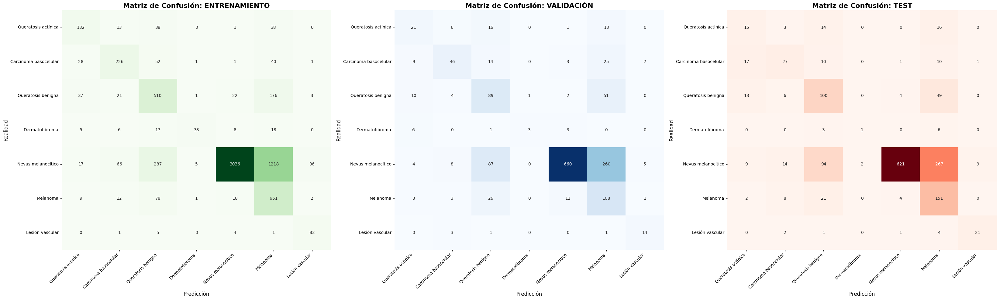

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos las matrices (la lógica sigue igual)
cm_train = confusion_matrix(y_true_train, y_pred_train)
cm_val = confusion_matrix(y_true_val, y_pred_val)
cm_test = confusion_matrix(y_true_test, y_pred_test)
# 2. Configuramos el gráfico
fig, ax = plt.subplots(1, 3, figsize=(33, 10)) # Aumentamos un poco el tamaño

# Matriz de Entrenamiento (Verde)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False) # Quitamos la barra lateral para ganar espacio
ax[0].set_title('Matriz de Confusión: ENTRENAMIENTO', fontsize=16, fontweight='bold')
ax[0].set_xlabel('Predicción', fontsize=12)
ax[0].set_ylabel('Realidad', fontsize=12)

# Matriz de Validación (Azul)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[1].set_title('Matriz de Confusión: VALIDACIÓN', fontsize=16, fontweight='bold')
ax[1].set_xlabel('Predicción', fontsize=12)
ax[1].set_ylabel('Realidad', fontsize=12)

# Matriz de Test (Roja)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', ax=ax[2],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[2].set_title('Matriz de Confusión: TEST', fontsize=16, fontweight='bold')
ax[2].set_xlabel('Predicción', fontsize=12)
ax[2].set_ylabel('Realidad', fontsize=12)

# --- AJUSTE CRÍTICO DE ETIQUETAS ---
# Rotamos las etiquetas de las X para que no se pisen
for a in ax:
    plt.sca(a)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 11: Inteligencia Artificial Explicable (XAI) - Grad-CAM
En esta sección visualizamos en qué regiones de la imagen se fija el modelo CoAtNet para clasificar las lesiones.


🚀 Generando tabla de: Aciertos del Modelo...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

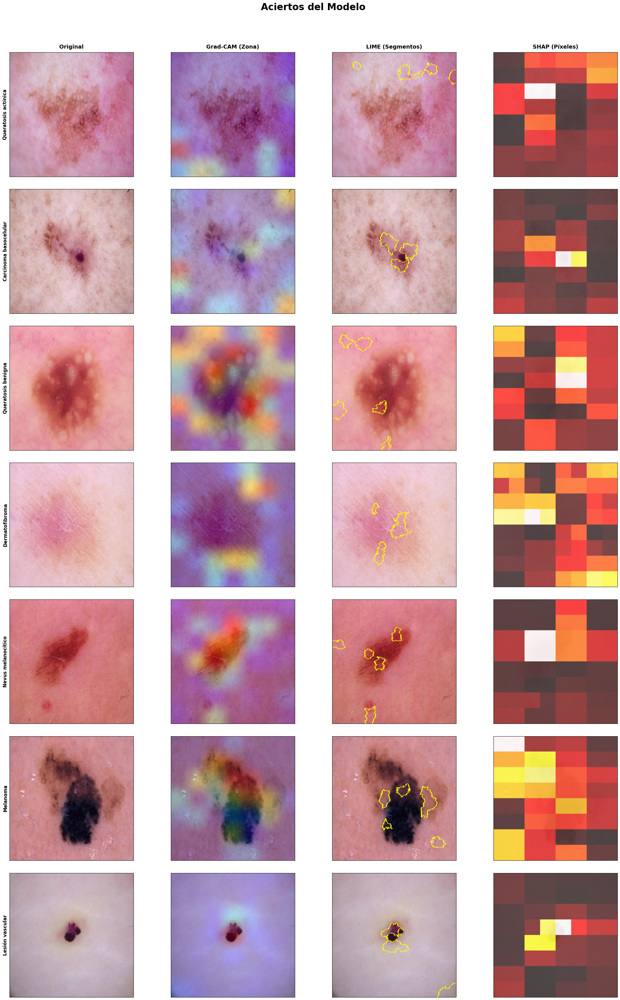


🚀 Generando tabla de: Fallos del Modelo (Errores de Predicción)...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

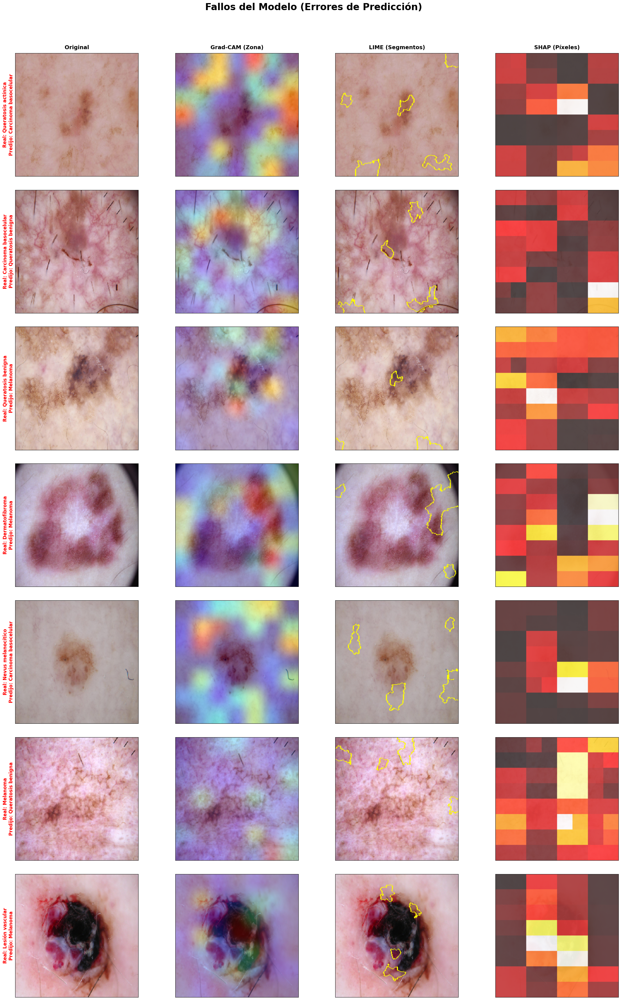

: 

In [ ]:
import matplotlib.cm as cm
import random
import contextlib
import shap
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries, quickshift
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. FUNCIONES CORE XAI
# ==========================================

def get_gradcam_heatmap(img_input, meta_input, model, last_conv_layer_name, pred_index):
    v_model = model.get_layer('coatnet0')
    inner_model = tf.keras.Model(
        inputs=v_model.inputs, 
        outputs=[v_model.get_layer(last_conv_layer_name).output, v_model.output]
    )
    pool_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.GlobalAveragePooling2D)][0]
    concat_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.Concatenate)][0]
    meta_branch = tf.keras.Model(inputs=model.input[1], outputs=concat_layer.input[1])
    
    top_input = tf.keras.Input(shape=concat_layer.output.shape[1:])
    x = top_input
    idx = model.layers.index(concat_layer)
    for layer in model.layers[idx+1:]:
        x = layer(x)
    top_model = tf.keras.Model(inputs=top_input, outputs=x)

    with tf.GradientTape() as tape:
        conv_output, backbone_out = inner_model(img_input)
        x_img = pool_layer(backbone_out)
        x_meta = meta_branch(meta_input)
        combined_features = concat_layer([x_img, x_meta])
        predictions = top_model(combined_features)
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def superimpose_heatmap(img_path, heatmap, alpha=0.4):
    img = tf.keras.utils.load_img(img_path)
    img_arr = tf.keras.utils.img_to_array(img)
    heatmap_arr = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heatmap = tf.keras.utils.array_to_img(jet[heatmap_arr]).resize((img_arr.shape[1], img_arr.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    return tf.keras.utils.array_to_img(jet_heatmap * alpha + img_arr)

# ==========================================
# 2. FUNCIÓN DE BÚSQUEDA INTELIGENTE
# ==========================================

def buscar_ejemplo(class_idx, test_df, mode='correct'):
    """ Busca en el set de test una imagen que el modelo haya acertado o fallado """
    df_filtrado = test_df[test_df['label'] == class_idx].sample(frac=1, random_state=42) # Aleatorizar
    
    for _, row in df_filtrado.iterrows():
        img_path = row['path']
        current_meta = np.array([row['meta']], dtype=np.float32)
        
        # Preparar imagen
        img_raw = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.utils.img_to_array(img_raw)
        img_input = np.expand_dims(img_array, axis=0) / 255.0
        
        # Predecir
        pred = final_model.predict([img_input, current_meta], verbose=0)
        pred_idx = np.argmax(pred[0])
        
        # Comprobar condición
        if mode == 'correct' and pred_idx == class_idx:
            return img_path, img_input, img_raw, current_meta, pred_idx
        elif mode == 'incorrect' and pred_idx != class_idx:
            return img_path, img_input, img_raw, current_meta, pred_idx
            
    return None # Si no encuentra ninguna (ej. si ha acertado el 100% no hay incorrectas)

# ==========================================
# 3. GENERACIÓN DE TABLAS
# ==========================================

sub_model = final_model.get_layer('coatnet0')
last_conv_name = [l.name for l in sub_model.layers if 'conv' in l.name.lower()][-1]
explainer_lime = lime_image.LimeImageExplainer()
col_titles = ['Original', 'Grad-CAM (Zona)', 'LIME (Segmentos)', 'SHAP (Píxeles)']

modos = ['correct', 'incorrect']
titulos_tabla = ["Aciertos del Modelo", "Fallos del Modelo (Errores de Predicción)"]

for mode, titulo in zip(modos, titulos_tabla):
    print(f"\n🚀 Generando tabla de: {titulo}...")
    
    n_clases = len(class_names)
    fig, axes = plt.subplots(nrows=n_clases, ncols=4, figsize=(22, 5 * n_clases))
    fig.suptitle(titulo, fontsize=24, fontweight='bold', y=1.02)
    
    # Silenciamos la verbosidad de SHAP y LIME
    with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        for i, nombre_clase in enumerate(class_names):
            
            # Buscar la imagen adecuada
            resultado = buscar_ejemplo(i, test_df, mode=mode)
            
            if resultado is None:
                # Si no hay errores para esta clase, mostramos un mensaje vacío
                axes[i, 0].text(0.5, 0.5, "Sin ejemplos disponibles", ha='center', va='center')
                axes[i, 0].set_ylabel(class_names_es[i], fontsize=12, fontweight='bold')
                for j in range(1, 4): axes[i, j].axis('off')
                continue
                
            img_path, img_input, img_raw, current_meta, pred_idx = resultado

            # C. WRAPPER PARA LIME/SHAP
            def hybrid_predict(batch):
                m_batch = np.repeat(current_meta, batch.shape[0], axis=0)
                return final_model.predict([batch, m_batch], verbose=0)

            # 1. Grad-CAM
            h_map = get_gradcam_heatmap(img_input, current_meta, final_model, last_conv_name, pred_idx)
            gcam_res = superimpose_heatmap(img_path, h_map).resize((224, 224))
            
            # 2. LIME
            exp = explainer_lime.explain_instance(
                img_input[0].astype('double'), hybrid_predict, 
                top_labels=1, num_samples=500,
                segmentation_fn=lambda x: quickshift(x, kernel_size=3, max_dist=6, ratio=0.5)
            )
            temp, mask = exp.get_image_and_mask(exp.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
            
            # 3. SHAP
            masker = shap.maskers.Image("blur(16,16)", shape=(224, 224, 3))
            expl_shap = shap.Explainer(hybrid_predict, masker, output_names=class_names_es)
            sv = expl_shap(img_input, max_evals=200, batch_size=50)
            abs_s = np.abs(sv.values[0, :, :, :, pred_idx]).sum(axis=-1)

            # --- RENDERIZADO ---
            axes[i, 0].imshow(img_raw)
            
            # Si es modo incorrecto, mostramos qué predijo realmente
            if mode == 'correct':
                etiqueta = class_names_es[i]
            else:
                etiqueta = f"Real: {class_names_es[i]}\nPredijo: {class_names_es[pred_idx]}"
                
            axes[i, 0].set_ylabel(etiqueta, fontsize=12, fontweight='bold', color='red' if mode=='incorrect' else 'black')
            
            axes[i, 1].imshow(gcam_res)
            axes[i, 2].imshow(mark_boundaries(temp, mask))
            axes[i, 3].imshow(img_raw, alpha=0.3)
            axes[i, 3].imshow(abs_s, cmap='hot', alpha=0.7)

            # Limpiar ejes y poner títulos solo en la primera fila
            for j in range(4):
                axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
                if i == 0: axes[i, j].set_title(col_titles[j], fontweight='bold', fontsize=14, pad=10)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    plt.show()